In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import joblib
import json
import seaborn as sns

from skopt import gp_minimize
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from skopt.utils import use_named_args
from skopt.space import Real, Integer, Categorical
import time
from mlforecast import MLForecast

from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoARIMA, MSTL, AutoETS

# Data processor
- selected weather features: radiation & temp
- Z-score scaler
- both sine & cosine function for time feature transformation: hour of day, day of week, day of year
- flag radiation > Q3 as 1 to identify statistical outliers
- flag low temp < 1% percentile as 1 & flag high temp > 99% percentile as 1
- flag weekend as 1
- add a min. load threshold based on visual check to remove anomoly
- add historical avg load at the same hour of day & day of week as input features

In [2]:
from data_processor import DataProcessor

In [3]:
# JSON Parser specifically for the API
def parse_json(json_payload):
    """Parses the specific JSON structure into a Pandas DataFrame."""
    times = json_payload['history']['times']
    data_dict = json_payload['history']['data']
    
    # Create DataFrame
    df = pd.DataFrame(data_dict)
    
    # Convert times to datetime and set as index
    df['times'] = pd.to_datetime(times)
    df.set_index('times', inplace=True)
    
    original_len = len(df)
    print(f"Original Data Length (raw rows): {original_len}")
    
    # Enforce 15-minute frequency to expose any completely missing rows
    df = df.asfreq('15min')
    print(f"Length after enforcing 15-minute frequency: {len(df)}")
    
    return df
    
def build_cv_folds(train_raw_data, n_splits=3):
    """Fit/transform DataProcessor independently per fold. Returns list of 
    (X_tr, y_tr, X_val, y_val) tuples — computed once, reused for every model."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    
    print("\n--- Generating Leakage-Free CV Folds ---")
    for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(train_raw_data)):
        fold_train_raw = train_raw_data.iloc[tr_idx]
        fold_val_raw   = train_raw_data.iloc[val_idx]

        fold_processor = DataProcessor()
        fold_processor.fit(fold_train_raw)

        fold_train_clean = fold_processor.transform(fold_train_raw)
        fold_val_clean   = fold_processor.transform(fold_val_raw)

        X_tr = fold_train_clean.drop(columns=['y'])
        y_tr = fold_train_clean['y']
        
        X_val = fold_val_clean.drop(columns=['y'])
        y_val = fold_val_clean['y']
        
        folds.append((X_tr, y_tr, X_val, y_val))
        print(f"Prepared Fold {fold_idx+1}: Train={len(X_tr)} rows | Val={len(X_val)} rows")
        
    return folds

def cv_score(model_class, folds, **model_kwargs):
    """Scores a model across the pre-built, leakage-free folds."""
    scores = []
    for X_tr, y_tr, X_val, y_val in folds:
        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        # We calculate MSE. Lower is better for the Bayesian Optimizer.
        scores.append(mean_squared_error(y_val, preds))
    return np.mean(scores)

# Test code execution & data visualization
- parse data -> split data -> implement data processor (fit -> transform)
- visualize historical data with the flag boundary
- correlation matrix to check the relevance of selected features

--- Parsing Data ---
Original Data Length (raw rows): 9440
Length after enforcing 15-minute frequency: 9440

--- Outlier Detection for Target Variable (y) ---
Found 3 outlier(s) dropping below 3000000:
 - Timestamp: 2023-11-01 23:30:00+00:00 | Value: 1968000.0
 - Timestamp: 2023-11-01 23:45:00+00:00 | Value: 1936000.0
 - Timestamp: 2023-11-02 00:00:00+00:00 | Value: 1968000.0

--- Plotting Full Historical Load (Before vs After) ---


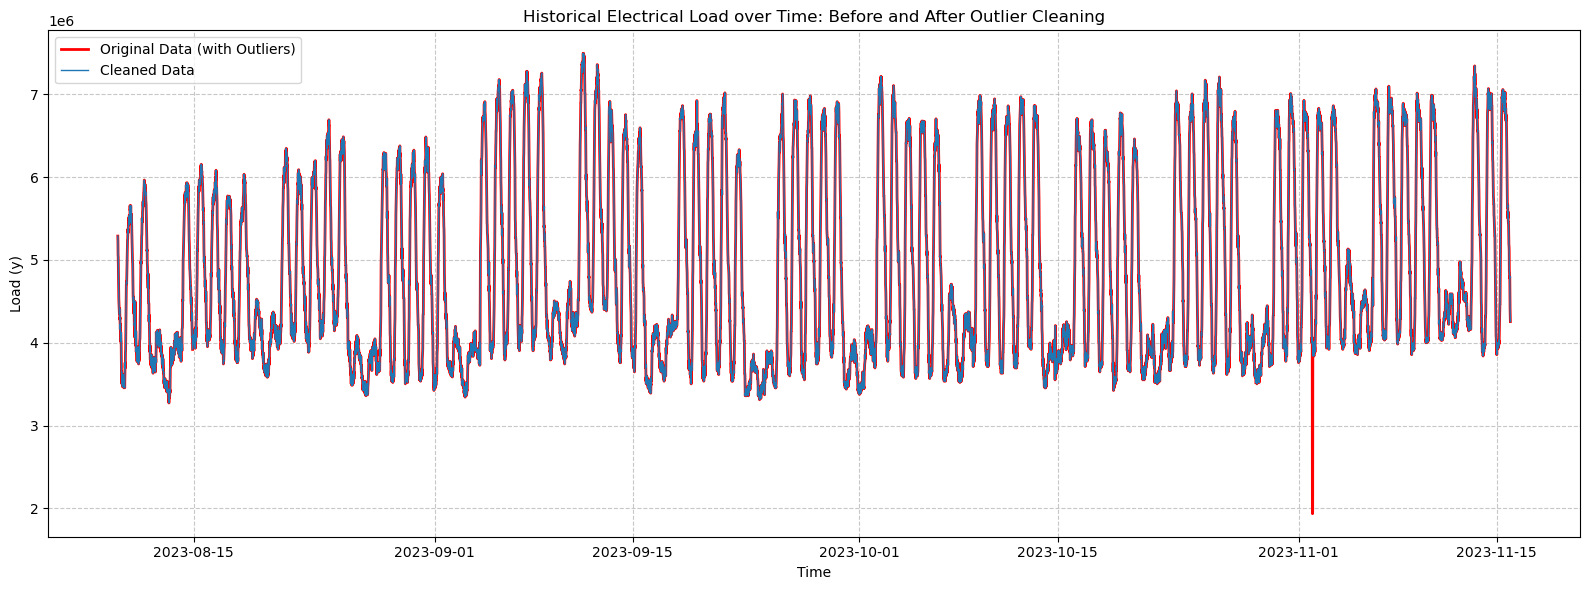

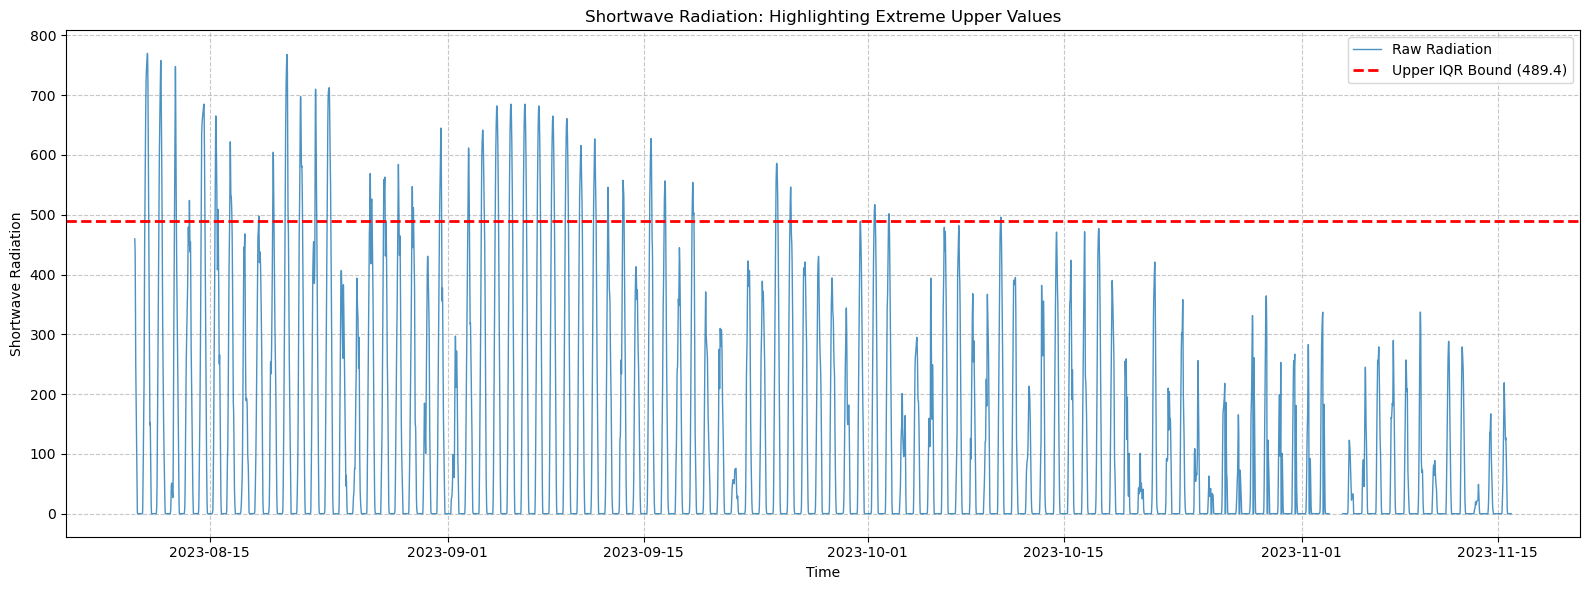

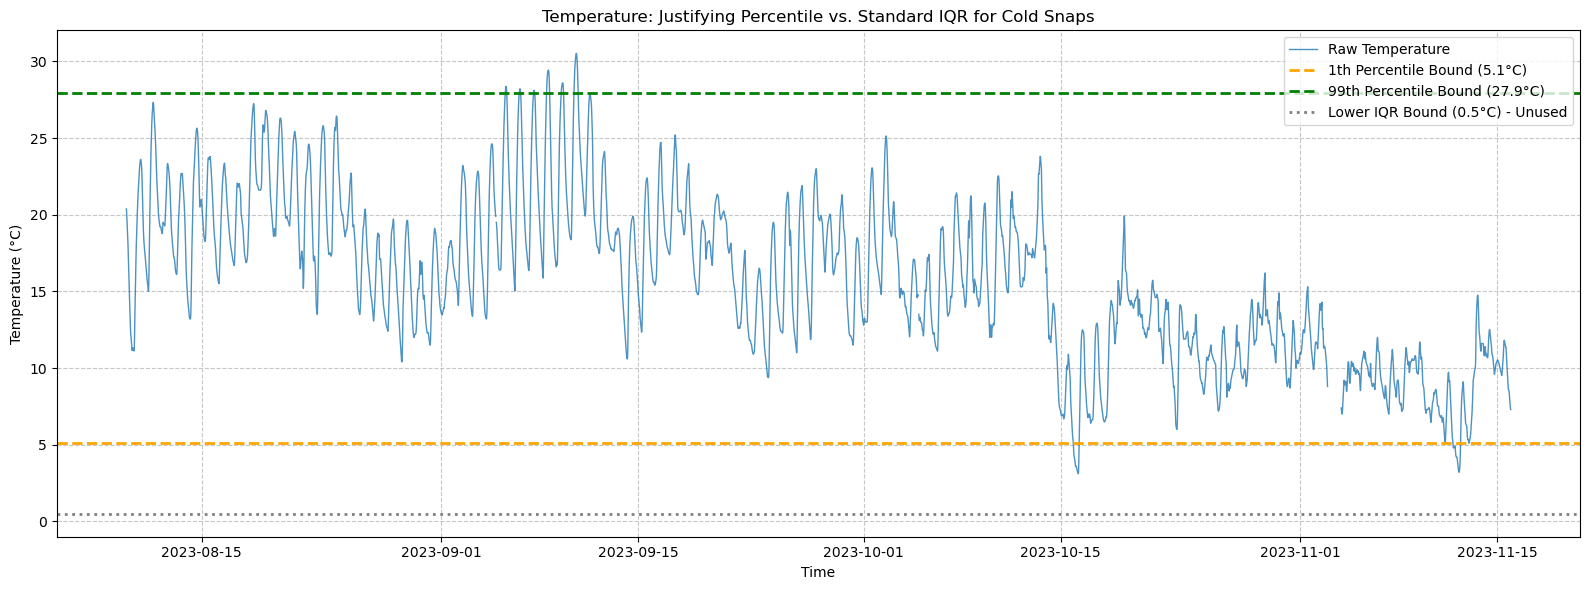


--- Splitting Data ---
Training data shape: (8608, 4)
Testing data shape: (832, 4)
Training Period: 2023-08-09 15:15:00+00:00  TO  2023-11-07 07:00:00+00:00
Testing Period:  2023-11-07 07:15:00+00:00  TO  2023-11-15 23:00:00+00:00

--- Raw Missing Values BEFORE Processing (Train) ---
shortwave_radiation    98
temperature_2m         98
y                      12
dtype: int64

--- Generating Leakage-Free CV Folds ---
Prepared Fold 1: Train=2152 rows | Val=2152 rows
Prepared Fold 2: Train=4304 rows | Val=2152 rows
Prepared Fold 3: Train=6456 rows | Val=2152 rows

--- Cleaned Train DataFrame Head (5) ---
                           shortwave_radiation  temperature_2m         y  \
times                                                                      
2023-08-09 15:15:00+00:00             1.804668        0.784158  0.410589   
2023-08-09 15:30:00+00:00             1.783460        0.777953  0.357317   
2023-08-09 15:45:00+00:00             1.742721        0.762202  0.205831   
2023-08-09 1

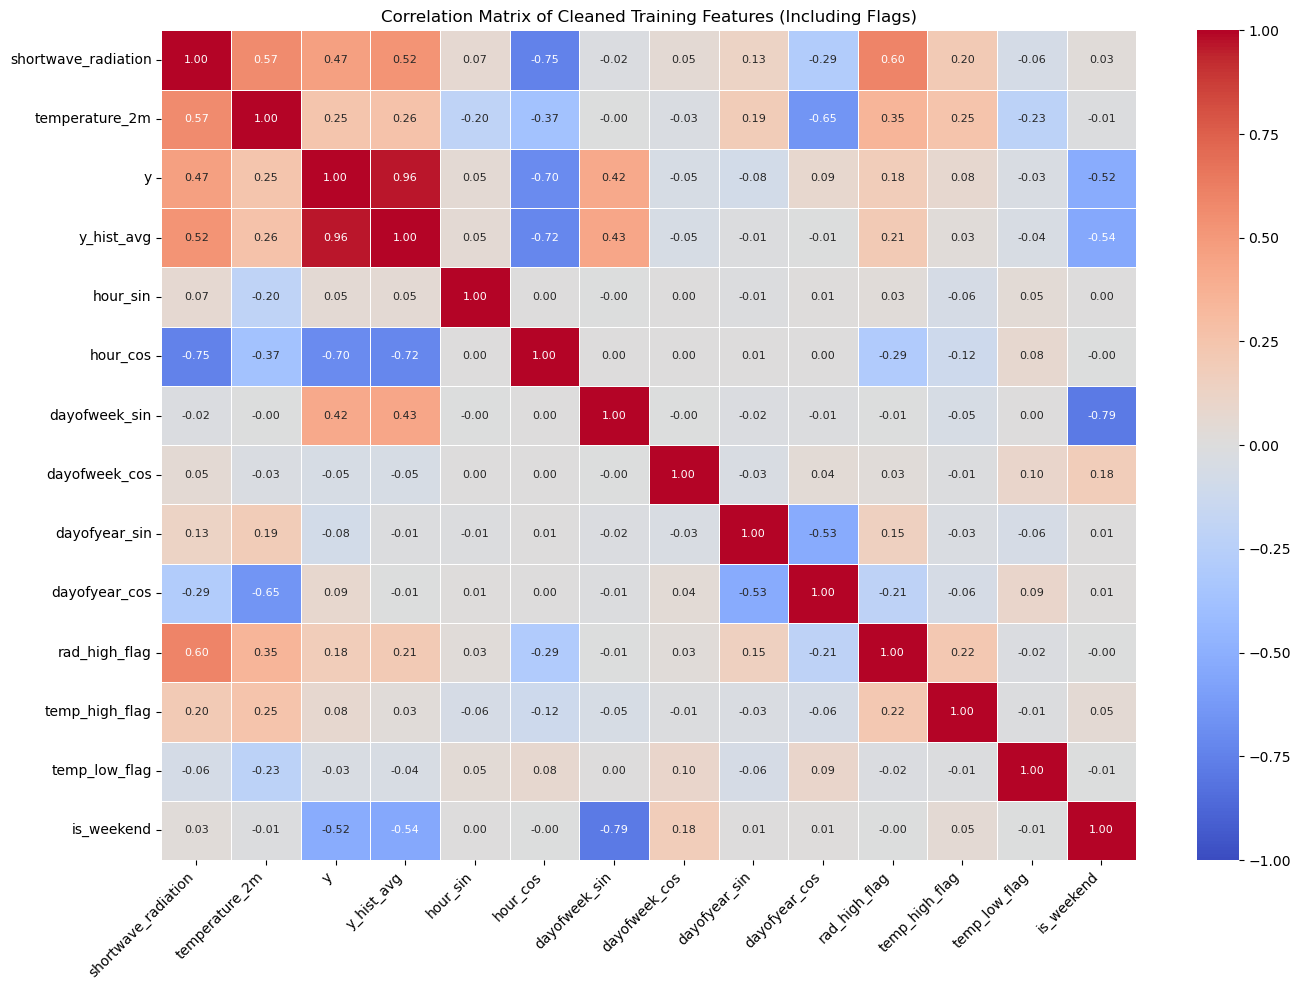

In [17]:
if __name__ == "__main__":
    
    # 1. DATA INGESTION
    with open("request_body (1).json", "r") as f:
        payload = json.load(f)

    print("--- Parsing Data ---")
    raw_df = parse_json(payload)

    # EXPLORATORY DATA ANALYSIS (EDA) & TARGET VALIDATION
    print("\n--- Outlier Detection for Target Variable (y) ---")
    Y_MIN_THRESHOLD = 3000000 
    
    outlier_mask = raw_df['y'] < Y_MIN_THRESHOLD
    outlier_timestamps = raw_df[outlier_mask].index
    
    print(f"Found {len(outlier_timestamps)} outlier(s) dropping below {Y_MIN_THRESHOLD}:")
    for ts in outlier_timestamps:
        print(f" - Timestamp: {ts} | Value: {raw_df.loc[ts, 'y']}")
        
    # Create a temporary series just for the plot so we don't leak into raw_df
    original_y = raw_df['y'].copy()
    plot_cleaned_y = original_y.copy()
    plot_cleaned_y.loc[outlier_mask] = np.nan
    plot_cleaned_y = plot_cleaned_y.interpolate(method='linear')
    
    # Plot Full Historical Load
    print("\n--- Plotting Full Historical Load (Before vs After) ---") 
    plt.figure(figsize=(16, 6))
    plt.plot(original_y.index, original_y, color='red', linewidth=2, label='Original Data (with Outliers)')
    plt.plot(plot_cleaned_y.index, plot_cleaned_y, color='#1f77b4', linewidth=1, label='Cleaned Data')
    
    plt.title("Historical Electrical Load over Time: Before and After Outlier Cleaning")
    plt.xlabel("Time")
    plt.ylabel("Load (y)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # WEATHER FEATURE ENGINEERING JUSTIFICATION PLOTS
    # Shortwave Radiation Plot (Upper IQR Flag)
    q1_rad = raw_df['shortwave_radiation'].quantile(0.25)
    q3_rad = raw_df['shortwave_radiation'].quantile(0.75)
    rad_upper_bound = q3_rad + 1.5 * (q3_rad - q1_rad)
    
    # Isolate flagged points for plotting
    rad_flagged = raw_df[raw_df['shortwave_radiation'] > rad_upper_bound]
    
    plt.figure(figsize=(16, 6))
    plt.plot(raw_df.index, raw_df['shortwave_radiation'], color='#1f77b4', linewidth=1, label='Raw Radiation', alpha=0.8)
    plt.axhline(rad_upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper IQR Bound ({rad_upper_bound:.1f})')
    
    plt.title("Shortwave Radiation: Highlighting Extreme Upper Values")
    plt.xlabel("Time")
    plt.ylabel("Shortwave Radiation")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Temperature Plot (5th Percentile vs IQR)
    temp_p01 = raw_df['temperature_2m'].quantile(0.01)
    temp_p99 = raw_df['temperature_2m'].quantile(0.99)
    q1_temp = raw_df['temperature_2m'].quantile(0.25)
    q3_temp = raw_df['temperature_2m'].quantile(0.75)
    temp_lower_iqr = q1_temp - 1.5 * (q3_temp - q1_temp)

    plt.figure(figsize=(16, 6))
    plt.plot(raw_df.index, raw_df['temperature_2m'], color='#1f77b4', linewidth=1, label='Raw Temperature', alpha=0.8)
    
    # Draw the effective 5th percentile bound
    plt.axhline(temp_p01, color='orange', linestyle='--', linewidth=2, label=f'1th Percentile Bound ({temp_p01:.1f}°C)')
    plt.axhline(temp_p99, color='green', linestyle='--', linewidth=2, label=f'99th Percentile Bound ({temp_p99:.1f}°C)')
    # Draw the ineffective IQR lower bound for visual justification
    plt.axhline(temp_lower_iqr, color='gray', linestyle=':', linewidth=2, label=f'Lower IQR Bound ({temp_lower_iqr:.1f}°C) - Unused')
    
    plt.title("Temperature: Justifying Percentile vs. Standard IQR for Cold Snaps")
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # CHRONOLOGICAL SPLIT (No modifications to raw_df)
    print("\n--- Splitting Data ---")
    train_raw, test_raw = train_test_split(raw_df, test_size=832, shuffle=False)
    print(f"Training data shape: {train_raw.shape}")
    print(f"Testing data shape: {test_raw.shape}")
    
    print(f"Training Period: {train_raw.index.min()}  TO  {train_raw.index.max()}")
    print(f"Testing Period:  {test_raw.index.min()}  TO  {test_raw.index.max()}")
    print("\n--- Raw Missing Values BEFORE Processing (Train) ---")
    print(train_raw[['shortwave_radiation', 'temperature_2m', 'y']].isna().sum())

    # CROSS-VALIDATION FOLD PREPARATION
    # Build the folds ONCE for your Bayesian Optimizer
    folds = build_cv_folds(train_raw, n_splits=3)

    # FINAL TEST SET PREPARATION
    processor = DataProcessor()
    processor.fit(train_raw) 
    train_clean = processor.transform(train_raw)
    test_clean = processor.transform(test_raw)
    print("\n--- Cleaned Train DataFrame Head (5) ---")
    print(train_clean.head(5))

    # 6. FEATURE CORRELATION CHECK
    corr = train_clean.select_dtypes(include=[np.number]).corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 8},
    )
    plt.title("Correlation Matrix of Cleaned Training Features (Including Flags)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # FINAL ARRAYS FOR MODELING
    X_train = train_clean.drop(columns=['y'])
    y_train = train_clean['y']

    X_test = test_clean.drop(columns=['y'])
    y_test = test_clean['y']

    # Scaling back the predictions to original units for metrics calculation
    y_idx = processor.scale_cols.index('y')
    y_std_watts = processor.scaler.scale_[y_idx]
    y_mean_watts = processor.scaler.mean_[y_idx]
    
    max_load_watts = train_raw['y'].max()
    max_load_kw = max_load_watts / 1000

    # PREPARING STATSFORECAST DATAFRAMES (UNSCALED, NO CYCLICAL/HIST FEATURES)
    y_test_kw = ((y_test * y_std_watts) + y_mean_watts) / 1000
    # 1. Training Data (from raw unscaled data, trimming down to 3 features)
    sf_train = pd.DataFrame({
        'unique_id': 'simpl_energy_asset',
        'ds': train_raw.index,
        'y': train_raw['y'],
        'temperature_2m': train_raw['temperature_2m'],
        'shortwave_radiation': train_raw['shortwave_radiation']
    })
    
    # Clean missing/outliers directly on this raw dataframe
    sf_train.loc[sf_train['y'] < Y_MIN_THRESHOLD, 'y'] = np.nan
    sf_train['y'] = sf_train['y'].interpolate(method='linear').ffill().bfill()
    sf_train['temperature_2m'] = sf_train['temperature_2m'].interpolate(method='linear').ffill().bfill()
    sf_train['shortwave_radiation'] = sf_train['shortwave_radiation'].interpolate(method='linear').ffill().bfill()

    # 2. Future Exogenous Data (Test Set - exact same 832 step window)
    sf_future_exog = pd.DataFrame({
        'unique_id': 'simpl_energy_asset',
        'ds': test_raw.index,
        'temperature_2m': test_raw['temperature_2m'],
        'shortwave_radiation': test_raw['shortwave_radiation']
    })
    sf_future_exog['temperature_2m'] = sf_future_exog['temperature_2m'].interpolate(method='linear').ffill().bfill()
    sf_future_exog['shortwave_radiation'] = sf_future_exog['shortwave_radiation'].interpolate(method='linear').ffill().bfill()   

# ML Model Training & Validation
- investigated models: RF, XGBoost, MLR, MLP
- Bayesian optimization with 3-fold CV to tune hyperparameters for RF, XGBoost, MLP
- Evaluation metrics: MAE, RMSE, NRMSE, R2

In [ ]:
pip install mlforecast lightgbm

In [ ]:
pip install statsforecast

In [ ]:
pip install xgboost

In [24]:
rf_space = [
    Integer(50, 500, name='n_estimators'),
    Integer(3, 15, name='max_depth'),
    Integer(2, 10, name='min_samples_split'),
    Integer(1, 5, name='min_samples_leaf'),
    Categorical([1.0, 'sqrt'], name='max_features') # Note: 1.0 replaces None for max_features in recent sklearn
]

# The objective function the Bayesian optimizer will try to minimize
@use_named_args(rf_space)
def rf_objective(**params):
    return cv_score(RandomForestRegressor, folds, random_state=42, **params)

rf_start_total = time.time()
# gp_minimize is the engine that powers BayesSearchCV
rf_res = gp_minimize(rf_objective, rf_space, n_calls=30, random_state=42)
rf_end_total = time.time()
rf_tuned_time = rf_end_total - rf_start_total
print(f"Total RF Optimization Time: {rf_tuned_time:.2f} seconds")

# Convert the optimal results list back into a dictionary
best_rf_params = {dim.name: val for dim, val in zip(rf_space, rf_res.x)}
print(f"Best RF Parameters: {best_rf_params}")
print(f"Best RF CV Score (MSE): {rf_res.fun:.4f}")

Total RF Optimization Time: 184.52 seconds
Best RF Parameters: {'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0}
Best RF CV Score (MSE): 0.1239


In [25]:
# Evaluate on the locked-away test set
rf_best = RandomForestRegressor(**best_rf_params, random_state=42)
rf_best.fit(X_train, y_train)
rf_start_test = time.perf_counter()
rf_preds = rf_best.predict(X_test)
rf_end_test = time.perf_counter()
rf_test_time = rf_end_test - rf_start_test
print(f"RF Prediction Time: {rf_test_time:.6f} seconds")


rf_rmse_kw = (root_mean_squared_error(y_test, rf_preds) * y_std_watts) / 1000
print(f"RF Test MAE: {(mean_absolute_error(y_test, rf_preds) * y_std_watts) / 1000:.4f} kW")
print(f"RF Test RMSE: {rf_rmse_kw:.4f} kW | NRMSE: {(rf_rmse_kw / max_load_kw):.4f} | R²: {r2_score(y_test, rf_preds):.4f}")

RF Prediction Time: 0.033890 seconds
RF Test MAE: 163.5479 kW
RF Test RMSE: 220.5080 kW | NRMSE: 0.0294 | R²: 0.9622


In [26]:
xgb_space = [
    Integer(50, 700, name='n_estimators'),
    Integer(3, 10, name='max_depth'),
    Real(0.01, 0.3, prior='log-uniform', name='learning_rate'),
    Real(0.5, 1.0, name='subsample'),
    Real(0.5, 1.0, name='colsample_bytree'),
    Integer(1, 20, name='min_child_weight')
]

@use_named_args(xgb_space)
def xgb_objective(**params):
    return cv_score(xgb.XGBRegressor, folds, objective='reg:squarederror', random_state=42, tree_method='exact', **params)

xgb_start_total = time.time()
xgb_res = gp_minimize(xgb_objective, xgb_space, n_calls=30, random_state=42)
xgb_end_total = time.time()
xgb_tuned_time = xgb_end_total - xgb_start_total
print(f"Total XGB Optimization Time: {xgb_tuned_time:.2f} seconds")

best_xgb_params = {dim.name: val for dim, val in zip(xgb_space, xgb_res.x)}
print(f"Best XGB Parameters: {best_xgb_params}")


Total XGB Optimization Time: 58.47 seconds
Best XGB Parameters: {'n_estimators': 523, 'max_depth': 5, 'learning_rate': 0.0696009102198762, 'subsample': 0.7604171300129119, 'colsample_bytree': 0.9805860121746747, 'min_child_weight': 17}


In [36]:
xgb_best = xgb.XGBRegressor(**best_xgb_params, objective='reg:squarederror', random_state=42, tree_method='exact')
xgb_best.fit(X_train, y_train)
xgb_start_test = time.perf_counter()
xgb_preds = xgb_best.predict(X_test)
xgb_end_test = time.perf_counter()
xgb_test_time = xgb_end_test - xgb_start_test
print(f"XGB Prediction Time: {xgb_test_time:.6f} seconds")

xgb_rmse_kw = (root_mean_squared_error(y_test, xgb_preds) * y_std_watts) / 1000
print(f"XGB Test MAE: {(mean_absolute_error(y_test, xgb_preds) * y_std_watts) / 1000:.4f} kW")
print(f"XGB Test RMSE: {xgb_rmse_kw:.4f} kW | NRMSE: {xgb_rmse_kw / max_load_kw:.4f} | R²: {r2_score(y_test, xgb_preds):.4f}")

XGB Prediction Time: 0.004750 seconds
XGB Test MAE: 182.6893 kW
XGB Test RMSE: 241.7121 kW | NRMSE: 0.0322 | R²: 0.9546


In [ ]:
mlr = PolynomialFeatures(degree=1)
x_mlr_train = mlr.fit_transform(X_train)

lin_mlr = LinearRegression()
start_mlr_train = time.time()
lin_mlr.fit(x_mlr_train, y_train)
end_mlr_train = time.time()
mlr_train_time = end_mlr_train - start_mlr_train
print(f"MLR Training Time: {mlr_train_time:.6f} seconds")

x_mlr_test = mlr.transform(X_test)
mlr_start_test = time.perf_counter()
mlr_preds = lin_mlr.predict(x_mlr_test)
mlr_end_test = time.perf_counter()
mlr_test_time = mlr_end_test - mlr_start_test
print(f"MLR Prediction Time: {mlr_test_time:.6f} seconds")

mlr_rmse_kw = (root_mean_squared_error(y_test, mlr_preds) * y_std_watts) / 1000
print(f"MLR Test MAE: {(mean_absolute_error(y_test, mlr_preds) * y_std_watts) / 1000:.4f} kW")
print(f"MLR Test RMSE: {mlr_rmse_kw:.4f} kW | NRMSE: {mlr_rmse_kw / max_load_kw:.4f} | R²: {r2_score(y_test, mlr_preds):.4f}")

MLR Training Time: 0.003547 seconds
MLR Prediction Time: 0.000279 seconds
MLR Test MAE: 313.3751 kW
MLR Test RMSE: 390.9888 kW | NRMSE: 0.0522 | R²: 0.8811


In [31]:
# Define the architectures in a list
mlp_architectures = [
    (8, 16), (16, 8), (16, 16), 
    (8, 8, 8), (32, 16, 8), (16, 16, 8), (16, 16, 16), (32, 32, 16), (32,32,32)
]

mlp_space = [
    Integer(0, len(mlp_architectures) - 1, name='arch_idx'),
    Categorical([0.001, 0.0001], name='learning_rate_init'),
    Categorical([0.001, 0.01, 1.0], name='alpha')
]

@use_named_args(mlp_space)
def mlp_objective(arch_idx, learning_rate_init, alpha):
    # Map the index back to the actual tuple for training
    hidden_layer_sizes = mlp_architectures[arch_idx]
    
    return cv_score(
        MLPRegressor, 
        folds, 
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        alpha=alpha,
        activation='relu', 
        solver='adam', 
        max_iter=1000, 
        random_state=42, 
        early_stopping=True
    )

mlp_start_total = time.time()
mlp_res = gp_minimize(mlp_objective, mlp_space, n_calls=30, random_state=42)
mlp_end_total = time.time()
mlp_tuned_time = mlp_end_total - mlp_start_total
print(f"Total MLP Optimization Time: {mlp_tuned_time:.2f} seconds")

# 3. Rebuild the final parameters by mapping the best index back to the tuple
best_mlp_params = {dim.name: val for dim, val in zip(mlp_space, mlp_res.x)}
best_arch_idx = best_mlp_params.pop('arch_idx') # Remove the index
best_mlp_params['hidden_layer_sizes'] = mlp_architectures[best_arch_idx] # Insert the actual tuple

print(f"Best MLP Parameters: {best_mlp_params}")

c:\Users\vivi6\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4, 0.001, 1.0] before, using random point [0, 0.001, 1.0]
  warnings.warn(


Total MLP Optimization Time: 174.24 seconds
Best MLP Parameters: {'learning_rate_init': 0.001, 'alpha': 1.0, 'hidden_layer_sizes': (32, 32, 16)}


In [33]:
mlp_best = MLPRegressor(**best_mlp_params, activation='relu', solver='adam', max_iter=5000, random_state=42, early_stopping=True)
mlp_best.fit(X_train, y_train)
mlp_start_test = time.perf_counter()
mlp_preds = mlp_best.predict(X_test)
mlp_end_test = time.perf_counter()
mlp_test_time = mlp_end_test - mlp_start_test
print(f"MLP Prediction Time: {mlp_test_time:.6f} seconds")

mlp_rmse_kw = (root_mean_squared_error(y_test, mlp_preds) * y_std_watts) / 1000
print(f"MLP Test MAE: {(mean_absolute_error(y_test, mlp_preds) * y_std_watts) / 1000:.4f} kW")
print(f"MLP Test RMSE: {mlp_rmse_kw:.4f} kW | NRMSE: {mlp_rmse_kw / max_load_kw:.4f} | R²: {r2_score(y_test, mlp_preds):.4f}")

MLP Prediction Time: 0.001235 seconds
MLP Test MAE: 194.3585 kW
MLP Test RMSE: 269.0766 kW | NRMSE: 0.0359 | R²: 0.9437


# Nixtla StatsForecast
Test MSTL

In [ ]:
# Initialize MSTL
sf_mstl = StatsForecast(
    models=[MSTL(season_length=[96, 672])], # 96 = daily, 672 = weekly
    freq='15min', 
    n_jobs=-1
)

# Train and track fit time
mstl_start_train = time.time()
sf_mstl.fit(df=sf_train)
mstl_end_train = time.time()
mstl_train_time = mstl_end_train - mstl_start_train
print(f"Total MSTL Training Time: {mstl_train_time:.2f} seconds")

Total MSTL Training Time: 8.40 seconds


In [ ]:
# Predict and track prediction time (passing future weather)
mstl_start_test = time.perf_counter()
sf_mstl_preds_df = sf_mstl.predict(h=len(sf_future_exog), X_df=sf_future_exog)
mstl_end_test = time.perf_counter()
mstl_test_time = mstl_end_test - mstl_start_test
print(f"MSTL Prediction Time: {mstl_test_time:.6f} seconds")

# Extract raw predictions and convert to kW directly
mstl_preds_kw = sf_mstl_preds_df['MSTL'].values / 1000

# Calculate Metrics against y_test_actual_kw
mstl_rmse_kw = root_mean_squared_error(y_test_kw, mstl_preds_kw)
mstl_mae_kw = mean_absolute_error(y_test_kw, mstl_preds_kw)
mstl_r2 = r2_score(y_test_kw, mstl_preds_kw)

print(f"MSTL Test MAE: {mstl_mae_kw:.4f} kW")
print(f"MSTL Test RMSE: {mstl_rmse_kw:.4f} kW | NRMSE: {mstl_rmse_kw / max_load_kw:.4f} | R²: {mstl_r2:.4f}")

MSTL Prediction Time: 0.041897 seconds
MSTL Test MAE: 216.1800 kW
MSTL Test RMSE: 285.3657 kW | NRMSE: 0.0381 | R²: 0.9367


# Model Performance Visaulization
- Prediction vs actual
- Error distribution
- Summary table

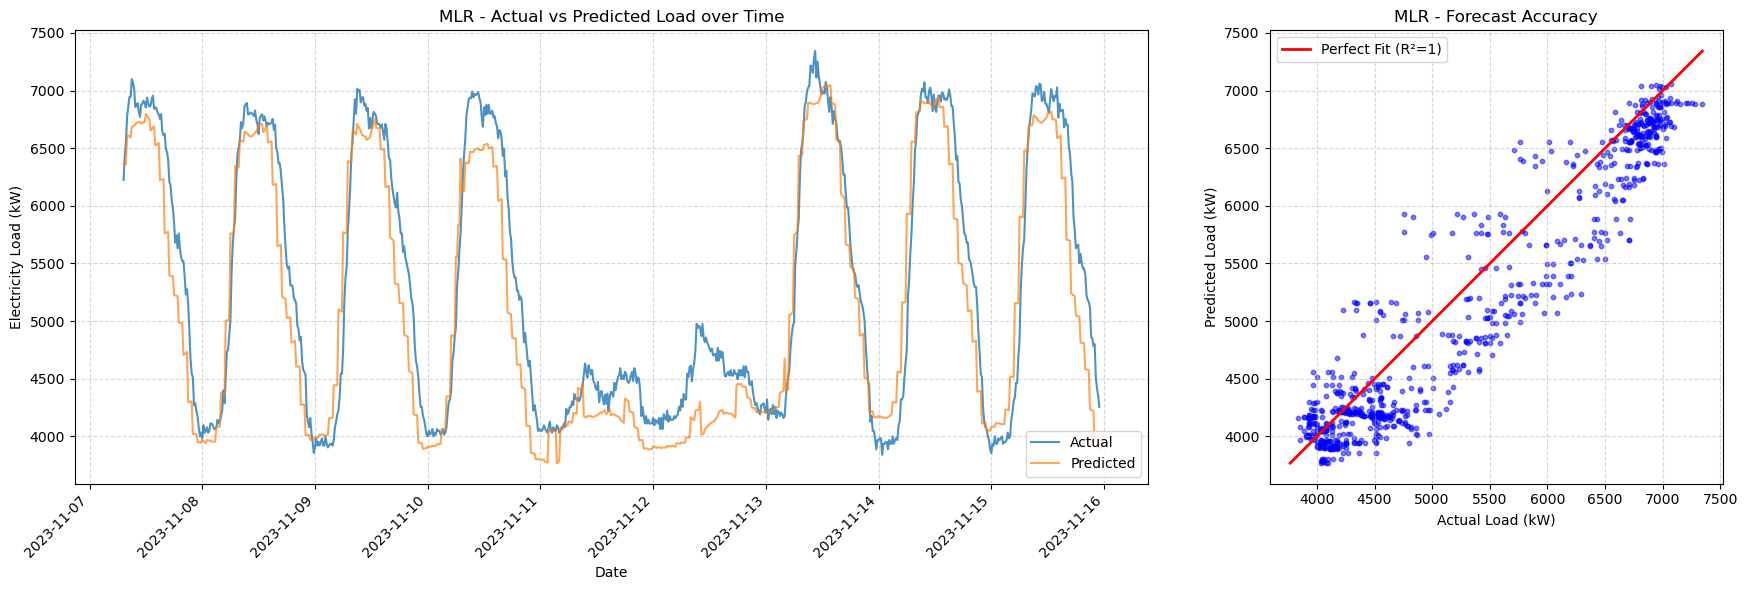

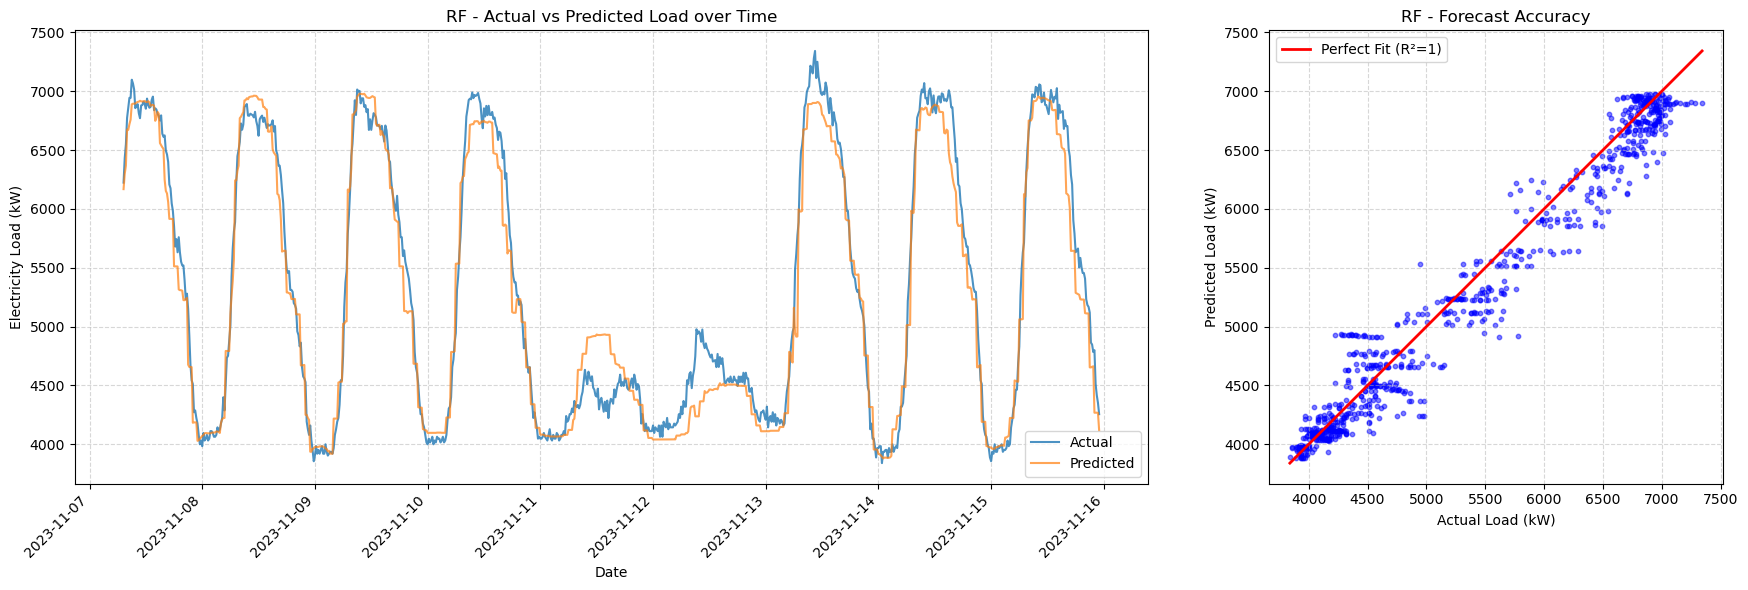

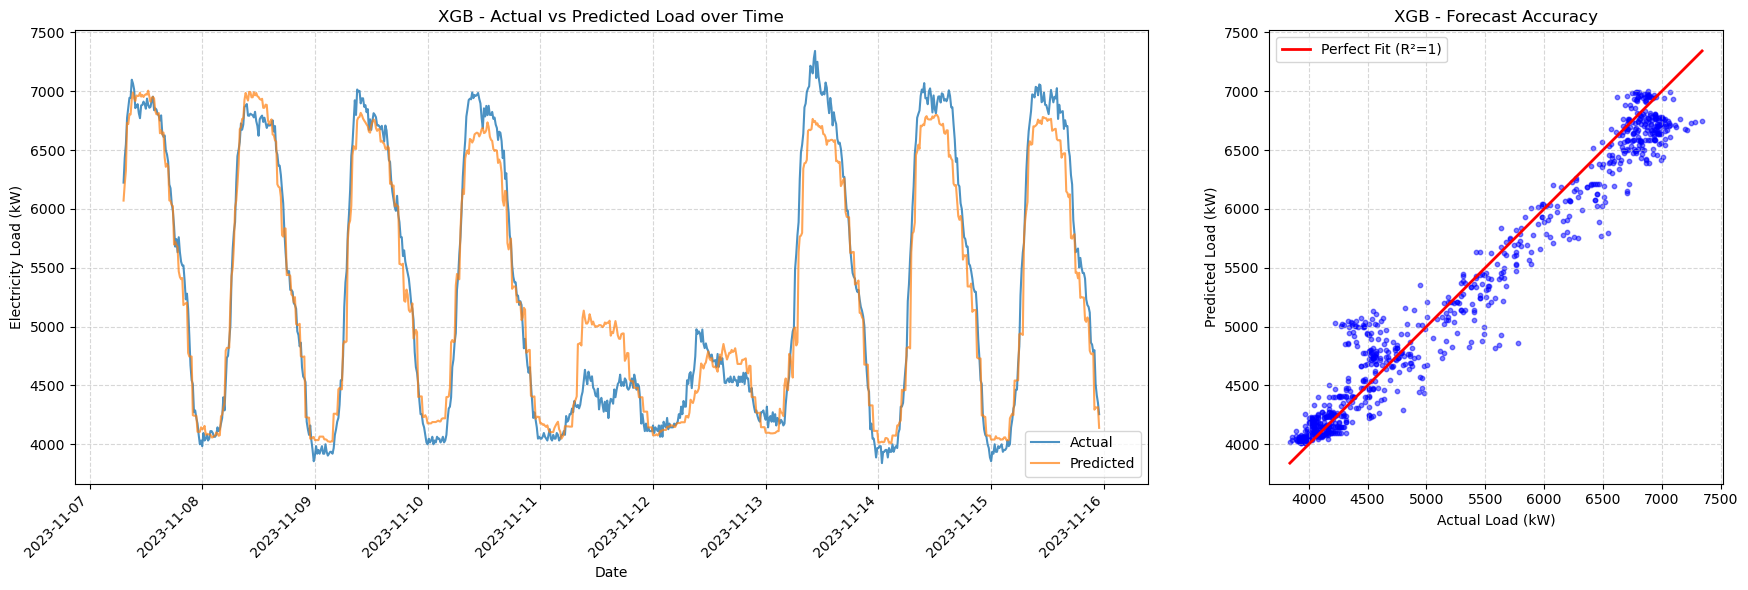

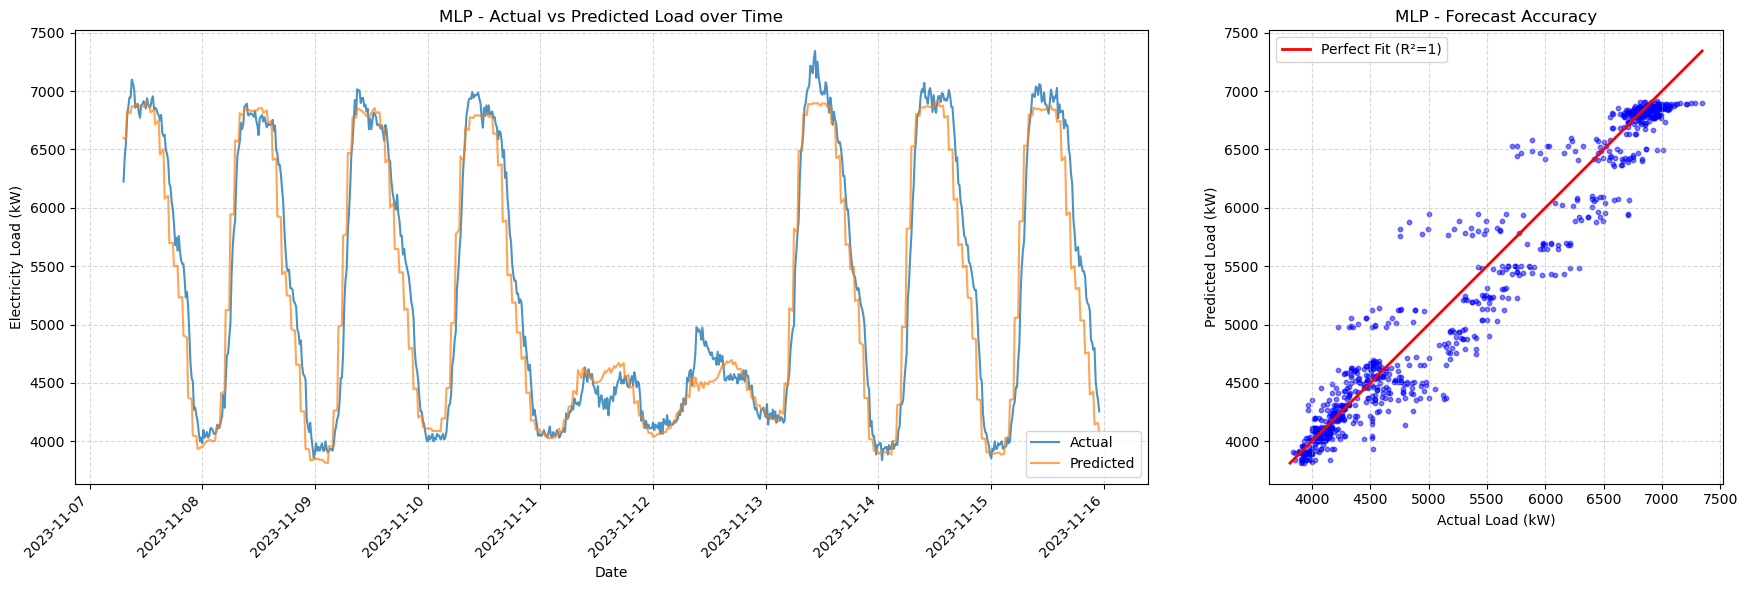

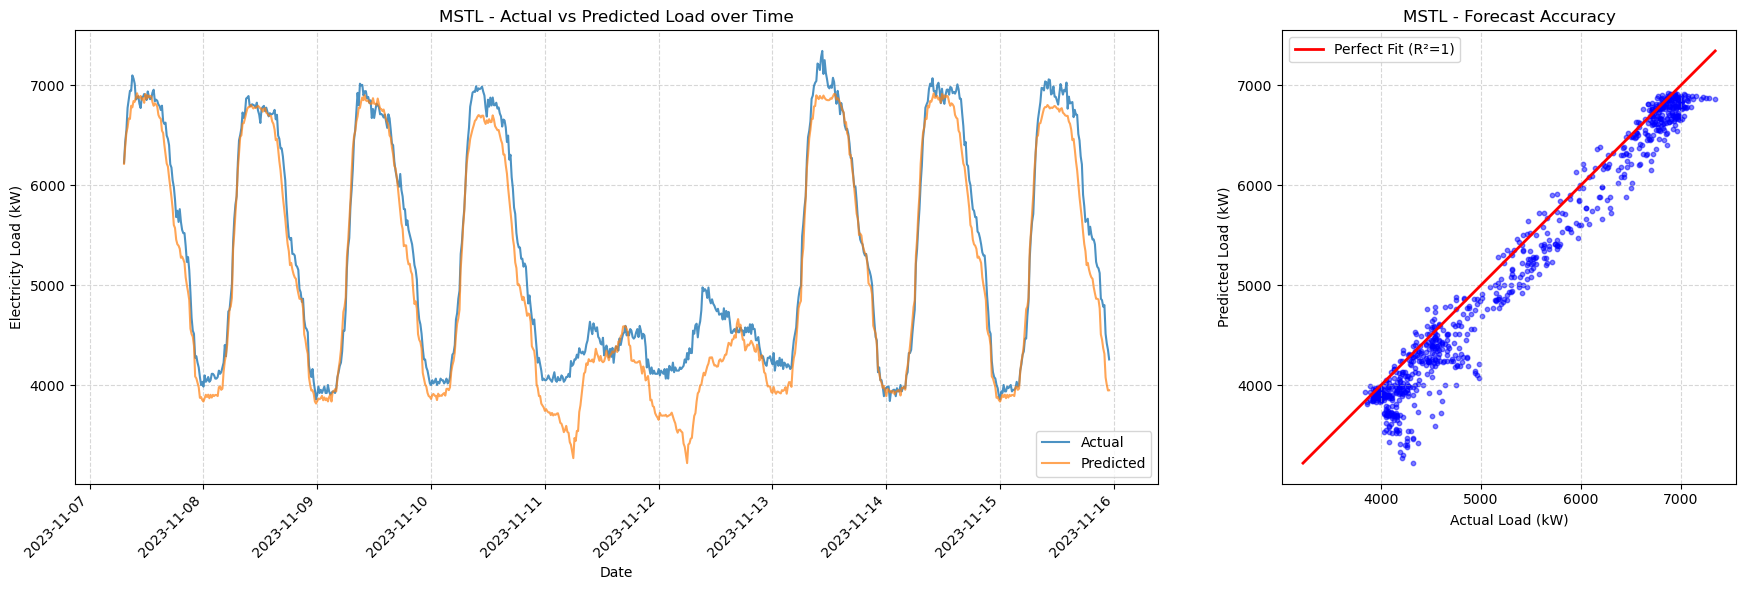

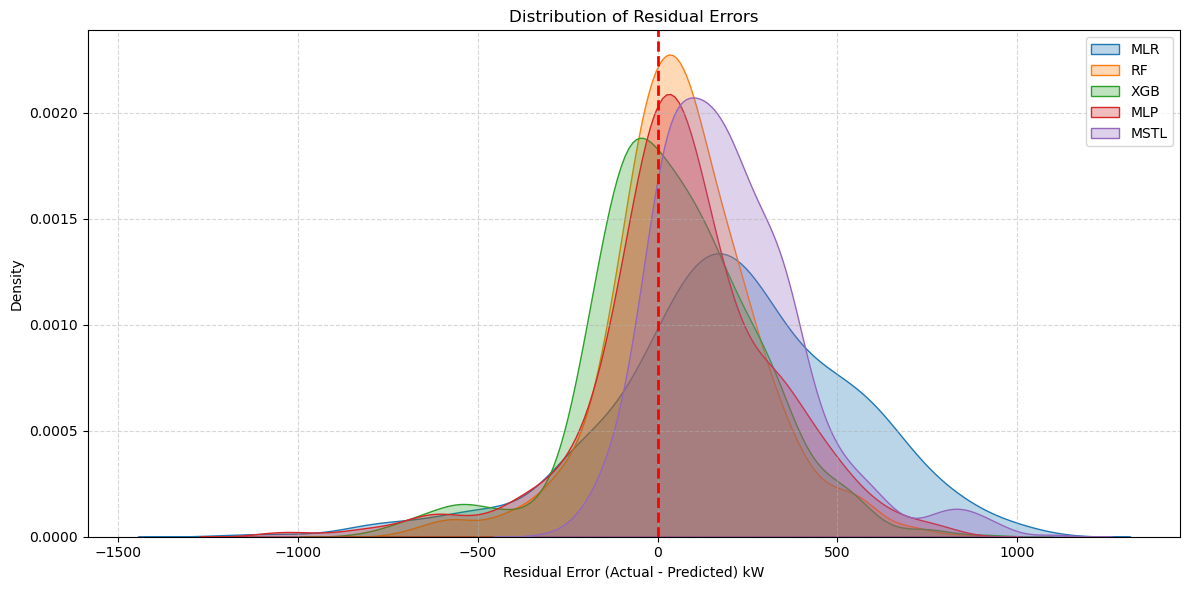

In [60]:
# 1. Consolidate Data & Convert back to real kW
# Math: Original = (Scaled * Std) + Mean
y_test_kw = ((y_test * y_std_watts) + y_mean_watts) / 1000

model_preds = {
    'MLR': ((mlr_preds * y_std_watts) + y_mean_watts) / 1000,
    'RF': ((rf_preds * y_std_watts) + y_mean_watts) / 1000,
    'XGB': ((xgb_preds * y_std_watts) + y_mean_watts) / 1000,
    'MLP': ((mlp_preds * y_std_watts) + y_mean_watts) / 1000,
    'MSTL': mstl_preds_kw
}


model_times = {
    'MLR': mlr_train_time,
    'RF': rf_tuned_time, 
    'XGB': xgb_tuned_time,       
    'MLP': mlp_tuned_time,
    'MSTL': mstl_train_time  
}


model_rmses = {
    'MLR': mlr_rmse_kw,
    'RF': rf_rmse_kw,
    'XGB': xgb_rmse_kw,
    'MLP': mlp_rmse_kw,
    'MSTL': mstl_rmse_kw
}

# Calculate Residuals (Error = Actual - Predicted)
model_residuals = {name: (y_test_kw - preds) for name, preds in model_preds.items()}

# ==========================================
# Predicted vs Actual (Time-Series & Scatter)
# ==========================================
for name, preds in model_preds.items():
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    # Time Series Comparison
    axes[0].plot(test_raw.index, y_test_kw, label='Actual', color='#1f77b4', alpha=0.8, linewidth=1.5)
    axes[0].plot(test_raw.index, preds, label='Predicted', color='#ff7f0e', alpha=0.7, linewidth=1.5)
    axes[0].set_title(f"{name} - Actual vs Predicted Load over Time")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Electricity Load (kW)")
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Format x-axis for dates
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Actual vs Predicted Scatter with R2=1 Line
    min_val = min(y_test_kw.min(), preds.min())
    max_val = max(y_test_kw.max(), preds.max())
    
    axes[1].scatter(y_test_kw, preds, color='blue', alpha=0.5, s=10)
    axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect Fit (R²=1)')
    axes[1].set_title(f"{name} - Forecast Accuracy")
    axes[1].set_xlabel("Actual Load (kW)")
    axes[1].set_ylabel("Predicted Load (kW)")
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Error Distribution Histogram
# ==========================================
plt.figure(figsize=(12, 6))
for name, resids in model_residuals.items():
    sns.kdeplot(resids, fill=True, alpha=0.3, label=name)

plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title("Distribution of Residual Errors")
plt.xlabel("Residual Error (Actual - Predicted) kW")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

| Model | Training/Opt Time (s) | Prediction Time (s) | MAE (kW) | RMSE (kW) | $R^2$ |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **RF** | 184.52 | 0.033890 | 163.5479 | 220.5080 | 0.9622 |
| **XGB** | 58.47 | 0.004750 | 182.6893 | 241.7121 | 0.9546 |
| **MLP** | 174.24 | 0.001235 | 194.3585 | 269.0766 | 0.9437 |
| **MSTL** | 8.40 | 0.041897 | 216.1800 | 285.3657 | 0.9367 |
| **MLR** | 0.003547 | 0.000279 | 313.3751 | 390.9888 | 0.8811 |

In [ ]:
# Save the best model and processor for application
joblib.dump(rf_best, 'best_rf_model.pkl')
joblib.dump(processor, 'data_processor.pkl')
print("Model and processor saved successfully!")

Model and processor saved successfully!
